# Завдання №2 - Розрахунок для 1-го рівня

In [11]:
import math
from scipy.special import comb

## Для Вейбула

### a_1W(k; t)

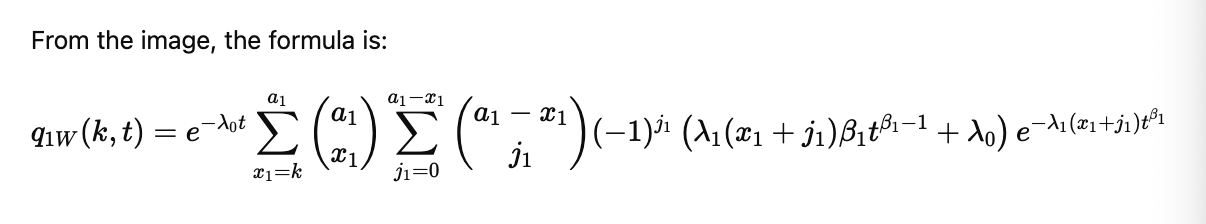

In [3]:
def a_1W(k, t, a1, lambda0, lambda1, beta1):
    """
    Compute:

    a_1W(k, t) =
    exp(-lambda0 * t) *
    sum_{x1=k}^{a1} C(a1, x1) *
        sum_{j1=0}^{a1-x1} C(a1-x1, j1) *
            (-1)^j1 *
            (lambda1*(x1+j1)*beta1*t^(beta1-1) + lambda0) *
            exp(-lambda1*(x1+j1)*t^beta1)
    """

    if k > a1:
        return 0.0

    outer_sum = 0.0

    for x1 in range(k, a1 + 1):
        comb1 = math.comb(a1, x1)
        inner_sum = 0.0

        for j1 in range(0, a1 - x1 + 1):
            comb2 = math.comb(a1 - x1, j1)
            sign = (-1) ** j1

            factor = (
                lambda1 * (x1 + j1) * beta1 * (t ** (beta1 - 1))
                + lambda0
            )

            exp_term = math.exp(
                -lambda1 * (x1 + j1) * (t ** beta1)
            )

            inner_sum += comb2 * sign * factor * exp_term

        outer_sum += comb1 * inner_sum

    return math.exp(-lambda0 * t) * outer_sum

In [6]:
value = a_1W(
    k=1,
    t=2.0,
    a1=5,
    lambda0=0.0001,
    lambda1=0.002,
    beta1=1.5
)

print(value)

9.998002335197022e-05


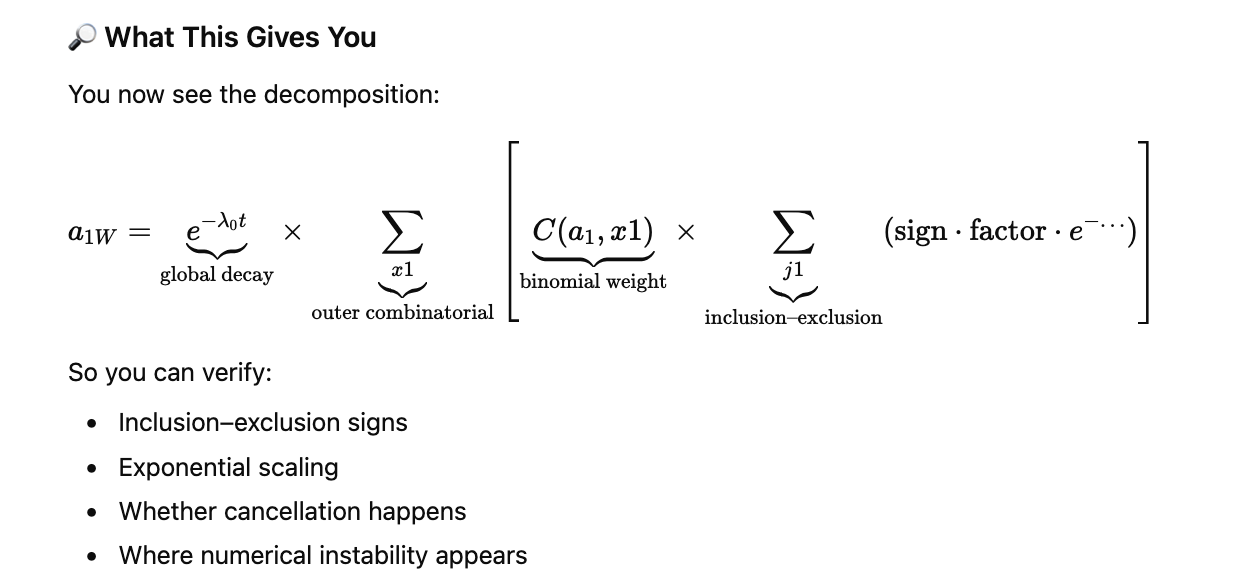

In [15]:
def a_1W_verbose(k, t, a1, lambda0, lambda1, beta1):
    if k > a1:
        print("k > a1 → result = 0")
        return 0.0

    outer_sum = 0.0

    print(f"\nComputing a_1W(k={k}, t={t})")
    print("=" * 60)

    for x1 in range(k, a1 + 1):
        comb1 = math.comb(a1, x1)
        inner_sum = 0.0

        print(f"\n--- x1 = {x1} ---")
        print(f"C(a1={a1}, x1={x1}) = {comb1}")

        for j1 in range(0, a1 - x1 + 1):
            comb2 = math.comb(a1 - x1, j1)
            sign = (-1) ** j1

            factor = (
                lambda1 * (x1 + j1) * beta1 * (t ** (beta1 - 1))
                + lambda0
            )

            exp_term = math.exp(
                -lambda1 * (x1 + j1) * (t ** beta1)
            )

            term = comb2 * sign * factor * exp_term
            inner_sum += term

            print(f"  j1 = {j1}")
            print(f"    C(a1-x1={a1-x1}, j1={j1}) = {comb2}")
            print(f"    sign = {sign}")
            print(f"    factor = {factor}")
            print(f"    exp_term = {exp_term}")
            print(f"    term contribution = {term}")

        outer_term = comb1 * inner_sum
        outer_sum += outer_term

        print(f"  → inner_sum (for x1={x1}) = {inner_sum}")
        print(f"  → outer contribution = {outer_term}")

    final_multiplier = math.exp(-lambda0 * t)
    result = final_multiplier * outer_sum

    print("\n" + "=" * 60)
    print(f"outer_sum = {outer_sum}")
    print(f"exp(-lambda0*t) = {final_multiplier}")
    print(f"FINAL RESULT = {result}")
    print("=" * 60)

    return result

In [16]:
a_1W_verbose(
    k=4,
    t=100.0,
    a1=5,
    lambda0=0.0002,
    lambda1=0.0002,
    beta1=1.3
)


Computing a_1W(k=4, t=100.0)

--- x1 = 4 ---
C(a1=5, x1=4) = 5
  j1 = 0
    C(a1-x1=1, j1=0) = 1
    sign = 1
    factor = 0.004340314573756372
    exp_term = 0.7272494510457467
    term contribution = 0.0031564913911301755
  j1 = 1
    C(a1-x1=1, j1=1) = 1
    sign = -1
    factor = 0.005375393217195466
    exp_term = 0.6715900491278006
    term contribution = -0.003610060594817549
  → inner_sum (for x1=4) = -0.0004535692036873734
  → outer contribution = -0.002267846018436867

--- x1 = 5 ---
C(a1=5, x1=5) = 1
  j1 = 0
    C(a1-x1=0, j1=0) = 1
    sign = 1
    factor = 0.005375393217195466
    exp_term = 0.6715900491278006
    term contribution = 0.003610060594817549
  → inner_sum (for x1=5) = 0.003610060594817549
  → outer contribution = 0.003610060594817549

outer_sum = 0.001342214576380682
exp(-lambda0*t) = 0.9801986733067553
FINAL RESULT = 0.0013156369470613328


0.0013156369470613328

### lambda_1W(k; t)

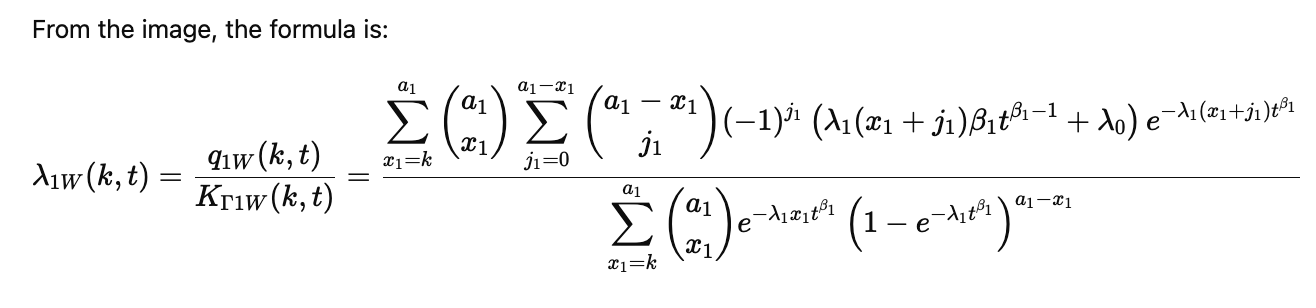

In [4]:
def numerator_q_1W(k, t, a1, lambda0, lambda1, beta1):
    outer_sum = 0.0

    for x1 in range(k, a1 + 1):
        comb1 = math.comb(a1, x1)
        inner_sum = 0.0

        for j1 in range(0, a1 - x1 + 1):
            comb2 = math.comb(a1 - x1, j1)
            sign = (-1) ** j1

            factor = (
                lambda1 * (x1 + j1) * beta1 * (t ** (beta1 - 1))
                + lambda0
            )

            exp_term = math.exp(
                -lambda1 * (x1 + j1) * (t ** beta1)
            )

            inner_sum += comb2 * sign * factor * exp_term

        outer_sum += comb1 * inner_sum

    return outer_sum


def denominator_K_gamma_1W(k, t, a1, lambda1, beta1):
    outer_sum = 0.0

    exp_base = math.exp(-lambda1 * (t ** beta1))
    one_minus = 1.0 - exp_base

    for x1 in range(k, a1 + 1):
        comb1 = math.comb(a1, x1)
        term = (
            comb1
            * math.exp(-lambda1 * x1 * (t ** beta1))
            * (one_minus ** (a1 - x1))
        )
        outer_sum += term

    return outer_sum


def lambda_1W(k, t, a1, lambda0, lambda1, beta1):
    num = numerator_q_1W(k, t, a1, lambda0, lambda1, beta1)
    denom = denominator_K_gamma_1W(k, t, a1, lambda1, beta1)

    if denom == 0:
        return float("inf")

    return num / denom

In [7]:
value = lambda_1W(
    k=1,
    t=2.0,
    a1=5,
    lambda0=0.0001,
    lambda1=0.002,
    beta1=1.5
)

print(value)

0.00010000002135694554


## Для Релея

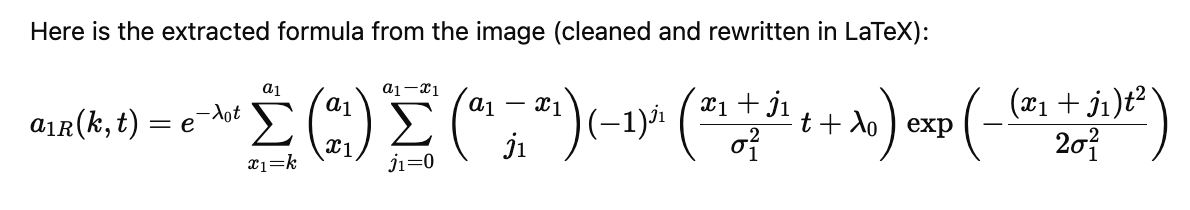

In [17]:
import math
from math import comb

def a_1R_verbose(k, t, a1, lambda0, sigma1):
    if k > a1:
        print("k > a1 → result = 0")
        return 0.0

    total_sum = 0.0

    print(f"\nComputing a_1R(k={k}, t={t})")
    print("=" * 60)

    for x1 in range(k, a1 + 1):
        binom1 = comb(a1, x1)
        inner_sum = 0.0

        print(f"\n--- x1 = {x1} ---")
        print(f"C(a1={a1}, x1={x1}) = {binom1}")

        for j1 in range(0, a1 - x1 + 1):
            binom2 = comb(a1 - x1, j1)
            sign = (-1) ** j1

            linear_factor = ((x1 + j1) / (sigma1 ** 2)) * t + lambda0

            exp_term = math.exp(
                -((x1 + j1) * t**2) / (2 * sigma1**2)
            )

            term = binom2 * sign * linear_factor * exp_term
            inner_sum += term

            print(f"  j1 = {j1}")
            print(f"    C(a1-x1={a1-x1}, j1={j1}) = {binom2}")
            print(f"    sign = {sign}")
            print(f"    linear_factor = {linear_factor}")
            print(f"    exp_term = {exp_term}")
            print(f"    term contribution = {term}")

        outer_term = binom1 * inner_sum
        total_sum += outer_term

        print(f"  → inner_sum (for x1={x1}) = {inner_sum}")
        print(f"  → outer contribution = {outer_term}")

    final_multiplier = math.exp(-lambda0 * t)
    result = final_multiplier * total_sum

    print("\n" + "=" * 60)
    print(f"total_sum = {total_sum}")
    print(f"exp(-lambda0*t) = {final_multiplier}")
    print(f"FINAL RESULT = {result}")
    print("=" * 60)

    return result

In [18]:
a_1R_verbose(
    k=2,
    t=100,
    a1=5,
    lambda0=0.0001,
    sigma1=920
)


Computing a_1R(k=2, t=100)

--- x1 = 2 ---
C(a1=5, x1=2) = 10
  j1 = 0
    C(a1-x1=3, j1=0) = 1
    sign = 1
    linear_factor = 0.0003362948960302457
    exp_term = 0.9882547752393218
    term contribution = 0.00033234503689050156
  j1 = 1
    C(a1-x1=3, j1=1) = 3
    sign = -1
    linear_factor = 0.00045444234404536863
    exp_term = 0.9824339959379804
    term contribution = -0.001339378823951742
  j1 = 2
    C(a1-x1=3, j1=2) = 3
    sign = 1
    linear_factor = 0.0005725897920604915
    exp_term = 0.9766475007833225
    term contribution = 0.001677655168169764
  j1 = 3
    C(a1-x1=3, j1=3) = 1
    sign = -1
    linear_factor = 0.0006907372400756144
    exp_term = 0.9708950878431577
    term contribution = -0.0006706333933797539
  → inner_sum (for x1=2) = -1.2012271230336415e-08
  → outer contribution = -1.2012271230336415e-07

--- x1 = 3 ---
C(a1=5, x1=3) = 10
  j1 = 0
    C(a1-x1=2, j1=0) = 1
    sign = 1
    linear_factor = 0.00045444234404536863
    exp_term = 0.982433995937980

9.900545518964038e-05

### lambda_1R(k; t)

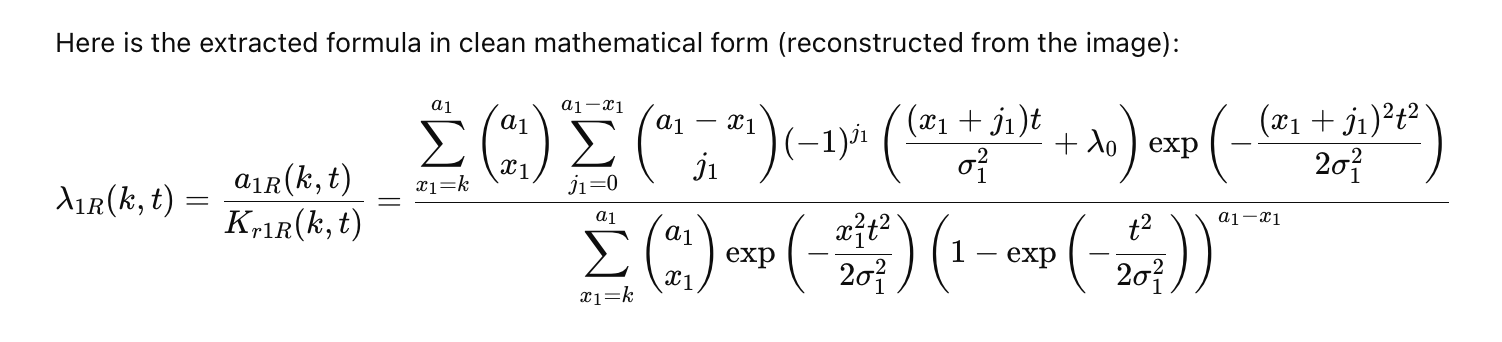

In [12]:
import numpy as np
from math import comb

In [13]:
def lambda_1R(k, t, a1, sigma1, lambda0):
    """
    Compute λ_{1R}(k, t)

    Parameters:
        k (int): lower summation index
        t (float): time parameter
        a1 (int): upper bound parameter
        sigma1 (float): sigma_1 parameter
        lambda0 (float): lambda_0 parameter

    Returns:
        float
    """

    numerator = 0.0
    denominator = 0.0

    exp_term_base = np.exp(-t**2 / (2 * sigma1**2))

    for x1 in range(k, a1 + 1):
        binom_a1_x1 = comb(a1, x1)

        # ----- Inner sum (numerator) -----
        inner_sum = 0.0
        for j1 in range(0, a1 - x1 + 1):
            binom_inner = comb(a1 - x1, j1)
            sign = (-1)**j1
            factor = ((x1 + j1) * t) / (sigma1**2) + lambda0
            exponential = np.exp(-((x1 + j1)**2 * t**2) / (2 * sigma1**2))

            inner_sum += binom_inner * sign * factor * exponential

        numerator += binom_a1_x1 * inner_sum

        # ----- Denominator term -----
        denom_term = (
            binom_a1_x1
            * np.exp(-(x1**2 * t**2) / (2 * sigma1**2))
            * (1 - exp_term_base)**(a1 - x1)
        )

        denominator += denom_term

    return numerator / denominator if denominator != 0 else np.nan

In [14]:
result = a_1R(
    k=2,
    t=1.0,
    a1=5,
    lambda0=0.3,
    sigma1=1.2
)

print(result)

0.34565100803512633
